In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [29]:
df = pd.read_excel("data/CleanSecurityData.xlsx")

df["Date"] = pd.to_datetime(df["date"])
df = df.sort_values(["cusip", "Date"])

df["DTS"] = df["spread"] * df["duration"]

df = df[df["spread"] != 0]
df = df[(df["spread"] > df["spread"].quantile(0.01)) &
        (df["spread"] < df["spread"].quantile(0.99))]
df = df[df["asset_type"] == "Credit"]

df["abs_spread_chg"] = df.groupby("cusip")["spread"].diff()
df["pct_spread_chg"] = df["abs_spread_chg"] / df["spread"]
df = df.dropna()

In [30]:
df["abs_vol"] = df.groupby("cusip")["abs_spread_chg"].rolling(36).std().reset_index(0, drop=True)
df["pct_vol"] = df.groupby("cusip")["pct_spread_chg"].rolling(36).std().reset_index(0, drop=True)
df = df.dropna()

df["excess_return_vol"] = df["DTS"] * df["pct_vol"]

b1 = df["spread"].quantile(0.33)
b2 = df["spread"].quantile(0.66)

df["bucket"] = np.where(df["spread"] < b1, "0",
                        np.where(df["spread"] < b2, "1", "2"))

df = df[df["spread"] >= 0.002]  


In [31]:
grouped = df.groupby(["Date","bucket"]).agg(
    abs_vol_mean=("abs_vol","mean"),
    count=("cusip","count"),
    DTS_mean=("DTS","mean"),
    excess_vol_mean=("excess_return_vol","mean")
).reset_index()

b0 = grouped[(grouped["bucket"] == "0") & (grouped["count"] > 5)]
b1 = grouped[(grouped["bucket"] == "1") & (grouped["count"] > 5)]
b2 = grouped[(grouped["bucket"] == "2") & (grouped["count"] > 5)]

combined = pd.concat([b0,b1,b2])

In [32]:
X = sm.add_constant(combined["DTS_mean"])
y = combined["excess_vol_mean"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        excess_vol_mean   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     1214.
Date:                Mon, 17 Nov 2025   Prob (F-statistic):          4.79e-160
Time:                        21:41:09   Log-Likelihood:                 3270.3
No. Observations:                 767   AIC:                            -6537.
Df Residuals:                     765   BIC:                            -6527.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      4.688      0.0

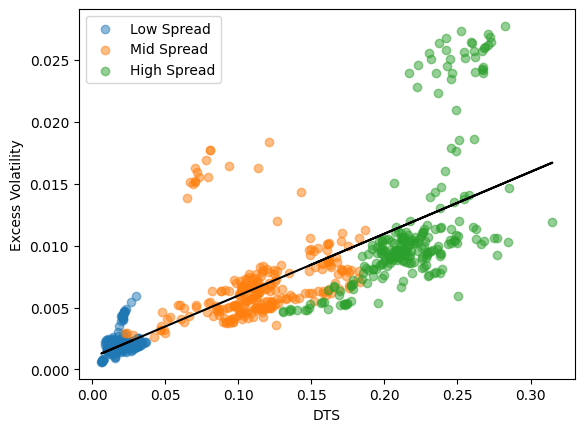

In [33]:
plt.scatter(b0["DTS_mean"], b0["excess_vol_mean"], alpha=0.5, label="Low Spread")
plt.scatter(b1["DTS_mean"], b1["excess_vol_mean"], alpha=0.5, label="Mid Spread")
plt.scatter(b2["DTS_mean"], b2["excess_vol_mean"], alpha=0.5, label="High Spread")

line_x = combined["DTS_mean"]
plt.plot(line_x, model.predict(sm.add_constant(line_x)), color="black")

plt.xlabel("DTS")
plt.ylabel("Excess Volatility")
plt.legend()
plt.show()

In [34]:
mask = ~combined["Date"].between("2020-01-01","2021-01-01")
filtered = combined[mask]

X2 = sm.add_constant(filtered["DTS_mean"])
y2 = filtered["excess_vol_mean"]
model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        excess_vol_mean   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     5738.
Date:                Mon, 17 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:41:09   Log-Likelihood:                 3562.7
No. Observations:                 657   AIC:                            -7121.
Df Residuals:                     655   BIC:                            -7112.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012   7.02e-05     17.776      0.0

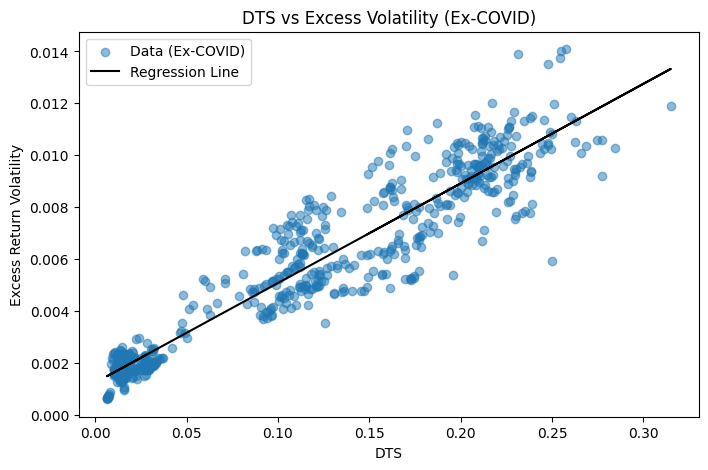

In [35]:
mask = ~combined["Date"].between("2020-01-01", "2021-01-01")
filtered = combined[mask]

plt.figure(figsize=(8,5))

plt.scatter(filtered["DTS_mean"], filtered["excess_vol_mean"],
            alpha=0.5, label="Data (Ex-COVID)")

plt.plot(filtered["DTS_mean"],
         model2.predict(sm.add_constant(filtered["DTS_mean"])),
         color="black", label="Regression Line")

plt.xlabel("DTS")
plt.ylabel("Excess Return Volatility")
plt.title("DTS vs Excess Volatility (Ex-COVID)")
plt.legend()
plt.show()